Dataset loaded successfully!

First 5 rows:


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1



Dataset Shape:
(11055, 32)

Column Names:
['index', 'having_IPhaving_IP_Address', 'URLURL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

Missing Values:
0

Target Class Distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64

Target labels after conversion:
0 = Legitimate
1 = Malicious

Class distribution:
Result
0    6157
1    4898
Name: count, dtype: int64

Training samples: 8844
Testing samples : 2211

Feature scaling completed!

Training SVM model...
SVM model trained successfully!

Predictions completed!


        SVM URL CLASS

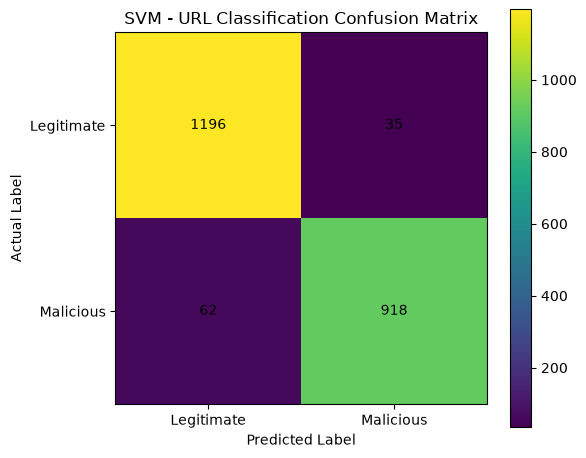



        SAMPLE URL CLASSIFICATIONS

Sample 1
Actual Class    : Malicious
Predicted Class : Malicious

Sample 2
Actual Class    : Malicious
Predicted Class : Malicious

Sample 3
Actual Class    : Malicious
Predicted Class : Malicious

Sample 4
Actual Class    : Malicious
Predicted Class : Malicious

Sample 5
Actual Class    : Legitimate
Predicted Class : Legitimate


                 OBSERVATION
The SVM model was successfully applied to classify URLs into Legitimate and Malicious categories.
The model achieved an accuracy of 95.61% on the test dataset.


In [1]:
# Experiment 5: Apply a Support Vector Machine (SVM) to classify URLs into legitimate and malicious categories 
# ================================================================
# SUPPORT VECTOR MACHINE (SVM) FOR URL CLASSIFICATION
# Classification: Legitimate vs Malicious/Phishing URLs
# ================================================================


# ================================================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Train-test split
from sklearn.model_selection import train_test_split

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Support Vector Machine
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ================================================================
# 2. LOAD THE DATASET
# ================================================================

# Make sure dataset.csv is in the same folder as your notebook

df = pd.read_csv("dataset.csv")

print("Dataset loaded successfully!")

# Display the first 5 rows
print("\nFirst 5 rows:")
display(df.head())


# ================================================================
# 3. CHECK THE DATASET
# ================================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nTarget Class Distribution:")
print(df["Result"].value_counts())


# ================================================================
# 4. PREPARE THE FEATURES AND TARGET
# ================================================================

# 'Result' is our target column.
#
# Result values:
#     1  = Legitimate
#    -1  = Malicious / Phishing
#
# The 'index' column is only a row identifier,
# so it should NOT be used as a feature.

X = df.drop(columns=["Result", "index"])

# Target variable
y = df["Result"]


# ================================================================
# 5. CONVERT TARGET LABELS
# ================================================================

# Convert:
# -1 = Malicious  -> 1
#  1 = Legitimate -> 0
#
# This makes the classification easier to interpret.

y = y.map({
    -1: 1,   # Malicious
     1: 0    # Legitimate
})


print("\nTarget labels after conversion:")
print("0 = Legitimate")
print("1 = Malicious")

print("\nClass distribution:")
print(y.value_counts())


# ================================================================
# 6. SPLIT DATA INTO TRAINING AND TESTING SETS
# ================================================================

# 80% of data will be used for training
# 20% will be used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ================================================================
# 7. FEATURE SCALING
# ================================================================

# SVM works better when numerical features are
# on a similar scale.
#
# StandardScaler converts the features so that
# they have approximately:
# mean = 0
# standard deviation = 1

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


# ================================================================
# 8. CREATE THE SVM MODEL
# ================================================================

# SVC = Support Vector Classifier
#
# kernel='rbf':
# Uses the Radial Basis Function kernel and can
# handle non-linear relationships in the data.
#
# C=1:
# Controls the trade-off between classification errors
# and model complexity.
#
# gamma='scale':
# Automatically determines a suitable gamma value.

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)


# ================================================================
# 9. TRAIN THE SVM MODEL
# ================================================================

print("\nTraining SVM model...")

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")


# ================================================================
# 10. MAKE PREDICTIONS
# ================================================================

# Predict the classes of the test data

y_pred = svm_model.predict(X_test_scaled)

print("\nPredictions completed!")


# ================================================================
# 11. CALCULATE PERFORMANCE METRICS
# ================================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ================================================================
# 12. DISPLAY PERFORMANCE
# ================================================================

print("\n")
print("=" * 50)
print("        SVM URL CLASSIFICATION RESULTS")
print("=" * 50)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

print("=" * 50)


# ================================================================
# 13. CLASSIFICATION REPORT
# ================================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Malicious"],
        zero_division=0
    )
)


# ================================================================
# 14. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ================================================================
# 15. VISUALIZE THE CONFUSION MATRIX
# ================================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM - URL Classification Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Labels for the two classes
plt.xticks(
    [0, 1],
    ["Legitimate", "Malicious"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Malicious"]
)

# Display the values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ================================================================
# 16. TEST A FEW EXISTING SAMPLES
# ================================================================

# Select 5 samples from the test dataset
sample_features = X_test.iloc[:5]

# Get their actual labels
sample_actual = y_test.iloc[:5]

# Scale the samples
sample_scaled = scaler.transform(sample_features)

# Predict using SVM
sample_predictions = svm_model.predict(sample_scaled)


print("\n")
print("=" * 50)
print("        SAMPLE URL CLASSIFICATIONS")
print("=" * 50)

for i in range(5):

    actual = (
        "Malicious"
        if sample_actual.iloc[i] == 1
        else "Legitimate"
    )

    predicted = (
        "Malicious"
        if sample_predictions[i] == 1
        else "Legitimate"
    )

    print(f"\nSample {i + 1}")
    print("Actual Class    :", actual)
    print("Predicted Class :", predicted)


# ================================================================
# 17. FINAL OBSERVATION
# ================================================================

print("\n")
print("=" * 50)
print("                 OBSERVATION")
print("=" * 50)

print(
    "The SVM model was successfully applied to classify "
    "URLs into Legitimate and Malicious categories."
)

print(
    f"The model achieved an accuracy of {accuracy * 100:.2f}% "
    "on the test dataset."
)

print("=" * 50)